In [1]:
print('')

## Import Lib + Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency

In [3]:
train = pd.read_csv('train.csv', sep=';')
train

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [4]:
test = pd.read_csv('test.csv', sep=';')
test

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


## EDA

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [7]:
train.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
test.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


## Train Distribution Check

In [9]:
sns.set_theme(style="whitegrid")

def plot_numeric_distribution(df, col, bins=40):
	fig, axes = plt.subplots(1, 2, figsize=(12, 4))
	sns.histplot(df[col], bins=bins, kde=True, ax=axes[0])
	axes[0].set_title(f"{col} — histogram")
	sns.boxplot(x=df[col], ax=axes[1])
	axes[1].set_title(f"{col} — boxplot")
	plt.tight_layout()
	plt.show()
	print(df[col].describe())

	q1, q3 = df[col].quantile([0.25, 0.75])
	iqr = q3 - q1
	lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
	outliers = df[col][(df[col] < lower) | (df[col] > upper)]
	print(f"IQR outlier bounds (1.5x rule): [{lower:.2f}, {upper:.2f}]")
	print(f"outliers: {len(outliers)} rows ({len(outliers) / len(df):.2%} of data)")
	if len(outliers):
		print(f"  below lower bound: {(outliers < lower).sum()}, above upper bound: {(outliers > upper).sum()}")

def plot_categorical_distribution(df, col, order=None):
	plt.figure(figsize=(8, 4))
	order = order or df[col].value_counts().index
	ax = sns.countplot(x=df[col], order=order)
	ax.set_title(f"{col} — value counts")
	plt.xticks(rotation=45, ha="right")
	plt.tight_layout()
	plt.show()
	print(df[col].value_counts(normalize=True).round(3))

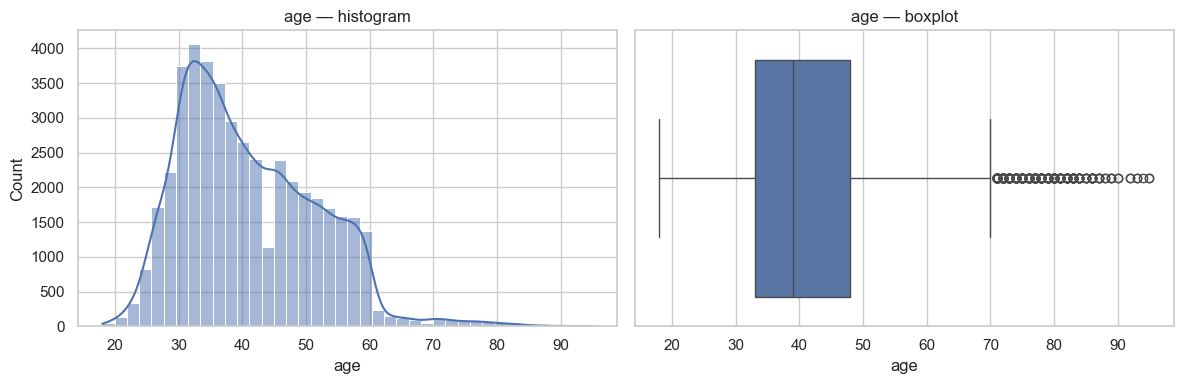

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64
IQR outlier bounds (1.5x rule): [10.50, 70.50]
outliers: 487 rows (1.08% of data)
  below lower bound: 0, above upper bound: 487


In [10]:
plot_numeric_distribution(train, "age")

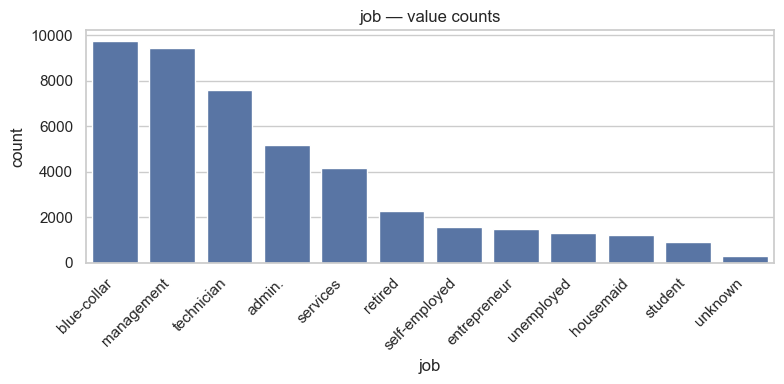

job
blue-collar      0.215
management       0.209
technician       0.168
admin.           0.114
services         0.092
retired          0.050
self-employed    0.035
entrepreneur     0.033
unemployed       0.029
housemaid        0.027
student          0.021
unknown          0.006
Name: proportion, dtype: float64


In [11]:
plot_categorical_distribution(train, "job")

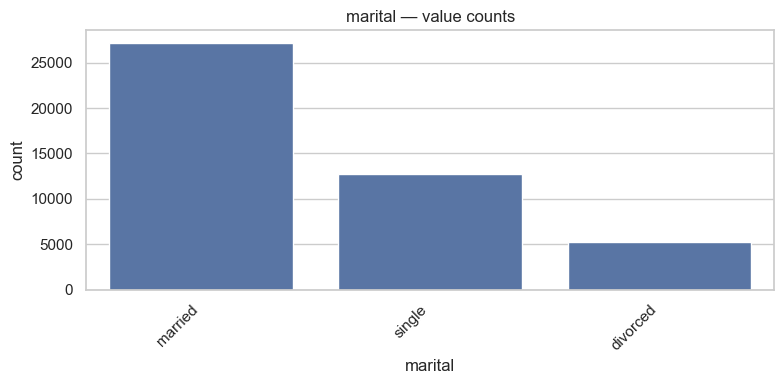

marital
married     0.602
single      0.283
divorced    0.115
Name: proportion, dtype: float64


In [12]:
plot_categorical_distribution(train, "marital")

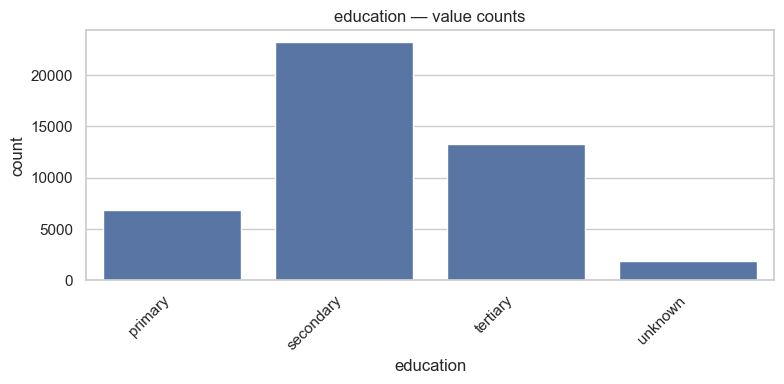

education
secondary    0.513
tertiary     0.294
primary      0.152
unknown      0.041
Name: proportion, dtype: float64


In [13]:
plot_categorical_distribution(train, "education", order=["primary", "secondary", "tertiary", "unknown"])

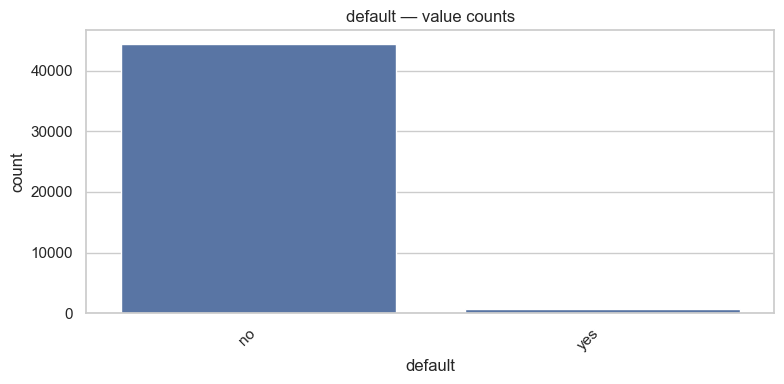

default
no     0.982
yes    0.018
Name: proportion, dtype: float64


In [14]:
plot_categorical_distribution(train, "default")

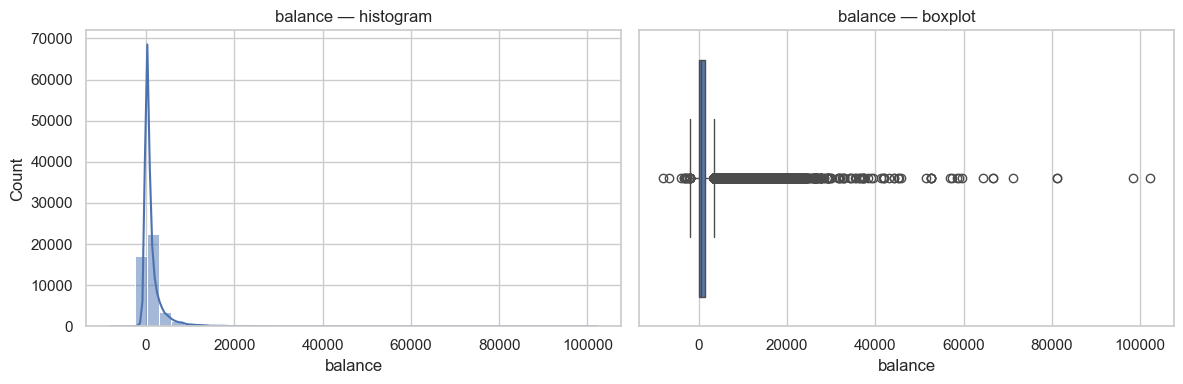

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64
IQR outlier bounds (1.5x rule): [-1962.00, 3462.00]
outliers: 4729 rows (10.46% of data)
  below lower bound: 17, above upper bound: 4712


In [15]:
plot_numeric_distribution(train, "balance")

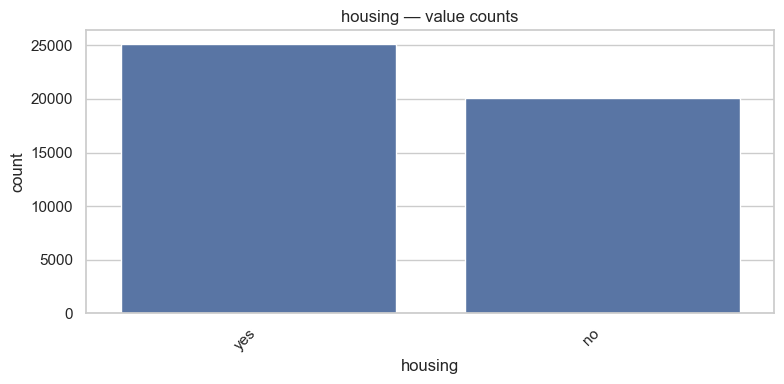

housing
yes    0.556
no     0.444
Name: proportion, dtype: float64


In [16]:
plot_categorical_distribution(train, "housing")

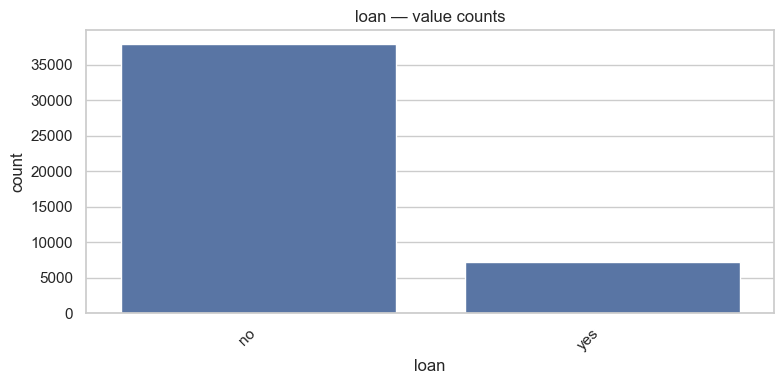

loan
no     0.84
yes    0.16
Name: proportion, dtype: float64


In [17]:
plot_categorical_distribution(train, "loan")

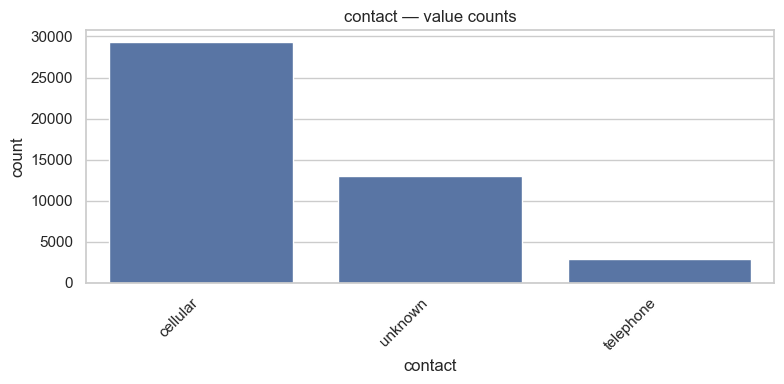

contact
cellular     0.648
unknown      0.288
telephone    0.064
Name: proportion, dtype: float64


In [18]:
plot_categorical_distribution(train, "contact")

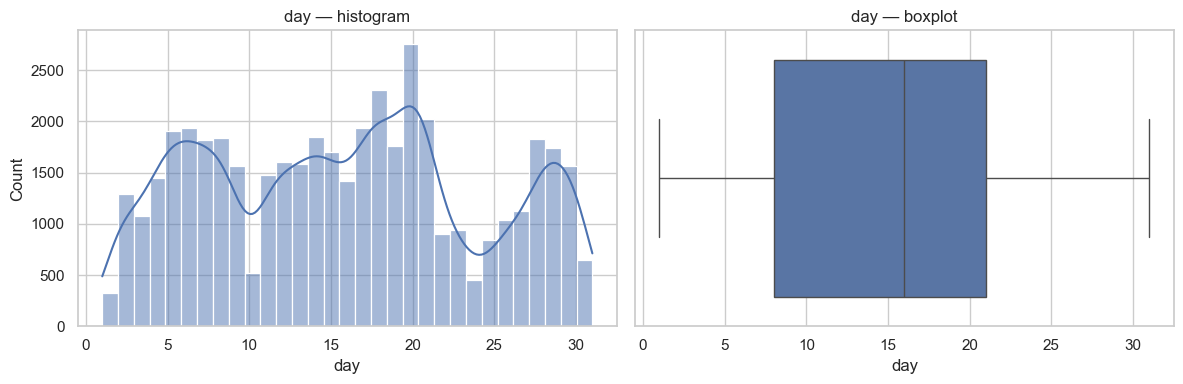

count    45211.000000
mean        15.806419
std          8.322476
min          1.000000
25%          8.000000
50%         16.000000
75%         21.000000
max         31.000000
Name: day, dtype: float64
IQR outlier bounds (1.5x rule): [-11.50, 40.50]
outliers: 0 rows (0.00% of data)


In [19]:
plot_numeric_distribution(train, "day", bins=31)

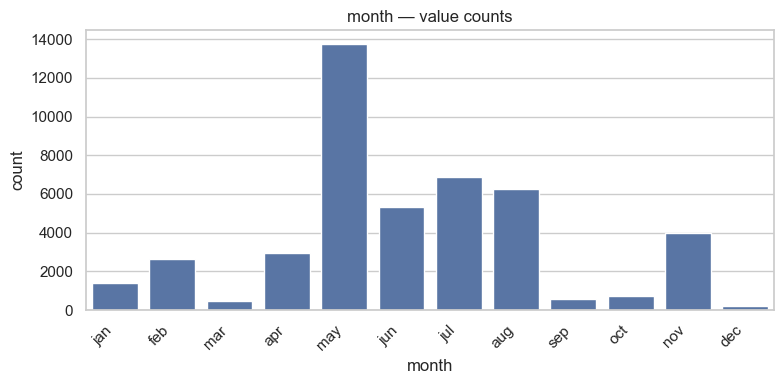

month
may    0.304
jul    0.153
aug    0.138
jun    0.118
nov    0.088
apr    0.065
feb    0.059
jan    0.031
oct    0.016
sep    0.013
mar    0.011
dec    0.005
Name: proportion, dtype: float64


In [20]:
month_order = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
plot_categorical_distribution(train, "month", order=month_order)

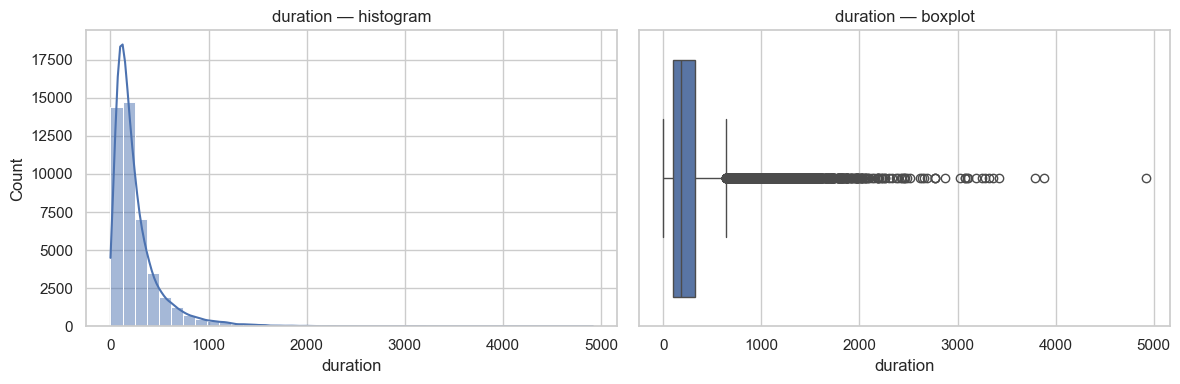

count    45211.000000
mean       258.163080
std        257.527812
min          0.000000
25%        103.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64
IQR outlier bounds (1.5x rule): [-221.00, 643.00]
outliers: 3235 rows (7.16% of data)
  below lower bound: 0, above upper bound: 3235


In [21]:
plot_numeric_distribution(train, "duration")

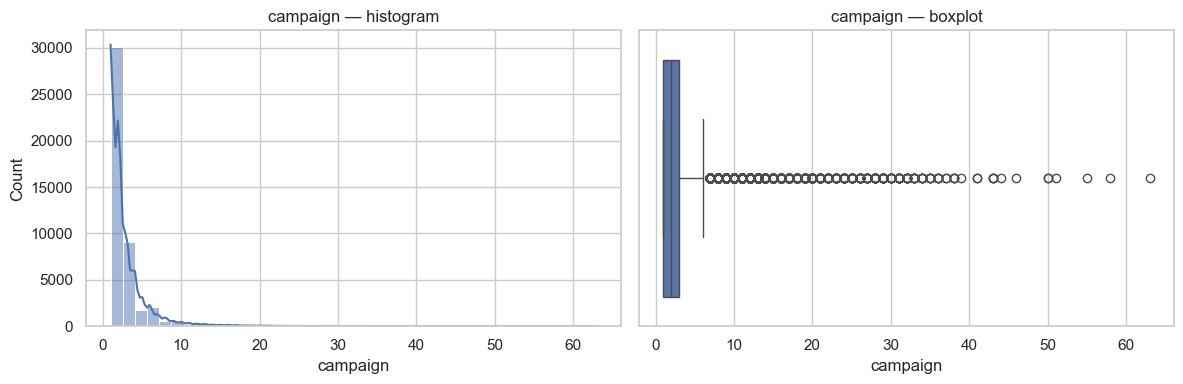

count    45211.000000
mean         2.763841
std          3.098021
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64
IQR outlier bounds (1.5x rule): [-2.00, 6.00]
outliers: 3064 rows (6.78% of data)
  below lower bound: 0, above upper bound: 3064


In [22]:
plot_numeric_distribution(train, "campaign")

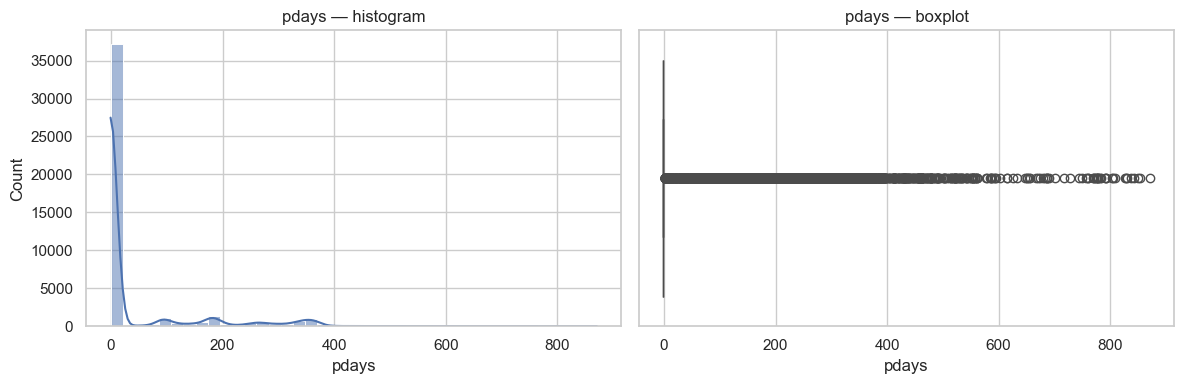

count    45211.000000
mean        40.197828
std        100.128746
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max        871.000000
Name: pdays, dtype: float64
IQR outlier bounds (1.5x rule): [-1.00, -1.00]
outliers: 8257 rows (18.26% of data)
  below lower bound: 0, above upper bound: 8257
never previously contacted (pdays == -1): 81.7% of clients


In [23]:
plot_numeric_distribution(train, "pdays")
print(f"never previously contacted (pdays == -1): {(train['pdays'] == -1).mean():.1%} of clients")

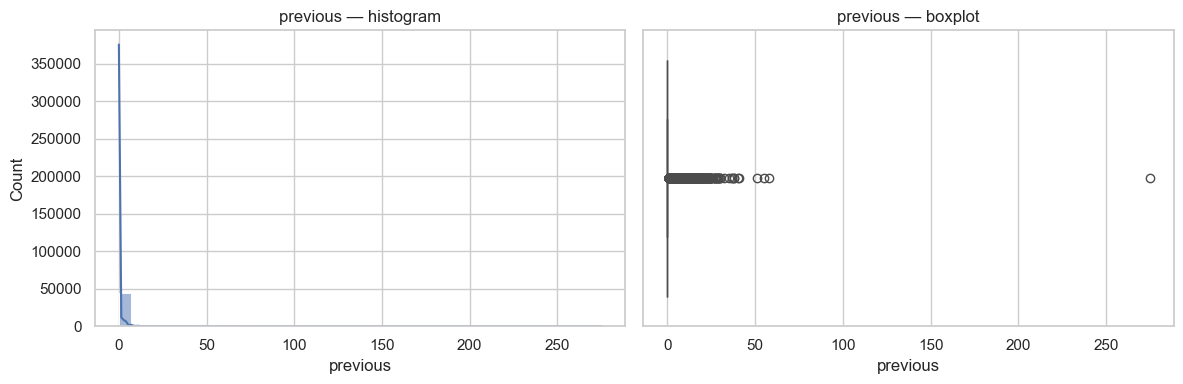

count    45211.000000
mean         0.580323
std          2.303441
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64
IQR outlier bounds (1.5x rule): [0.00, 0.00]
outliers: 8257 rows (18.26% of data)
  below lower bound: 0, above upper bound: 8257


In [24]:
plot_numeric_distribution(train, "previous")

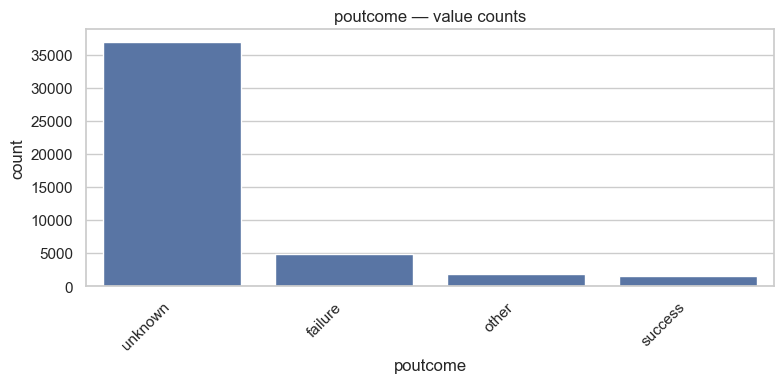

poutcome
unknown    0.817
failure    0.108
other      0.041
success    0.033
Name: proportion, dtype: float64


In [25]:
plot_categorical_distribution(train, "poutcome")

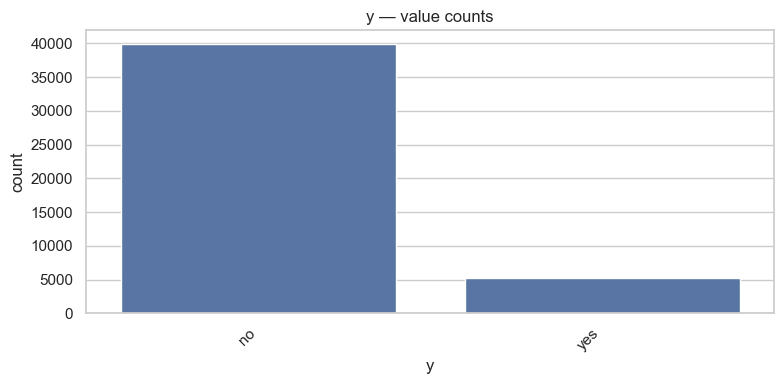

y
no     0.883
yes    0.117
Name: proportion, dtype: float64
class imbalance — 'yes' subscribers: 11.7%


In [26]:
plot_categorical_distribution(train, "y")
print(f"class imbalance — 'yes' subscribers: {(train['y'] == 'yes').mean():.1%}")

## Relevance vs. Classification Target (y) — Correlation First

In [27]:
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
categorical_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

y_binary = (train["y"] == "yes").astype(int)

def cramers_v(col, target):
	table = pd.crosstab(col, target)
	chi2 = chi2_contingency(table)[0]
	n = table.to_numpy().sum()
	r, k = table.shape
	return np.sqrt((chi2 / n) / (min(r, k) - 1))

relevance = {}
for col in numeric_cols:
	corr, _ = pointbiserialr(y_binary, train[col])
	relevance[col] = abs(corr)
for col in categorical_cols:
	relevance[col] = cramers_v(train[col], train["y"])

relevance = pd.Series(relevance).sort_values(ascending=False)
relevance_df = relevance.rename("relevance_score").to_frame()
relevance_df["type"] = ["numeric" if c in numeric_cols else "categorical" for c in relevance_df.index]
relevance_df

,relevance_score,type
duration,0.394521,numeric
poutcome,0.311663,categorical
month,0.260237,categorical
contact,0.151355,categorical
housing,0.139103,categorical
job,0.135990,categorical
pdays,0.103621,numeric
previous,0.093236,numeric
campaign,0.073172,numeric
education,0.072695,categorical


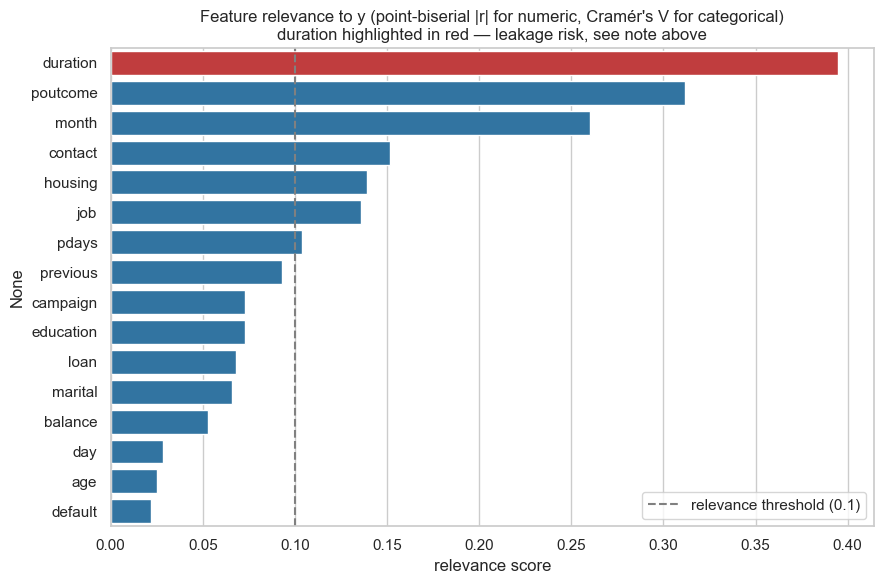

features clearing relevance threshold (0.1): ['duration', 'poutcome', 'month', 'contact', 'housing', 'job', 'pdays']


In [28]:
plt.figure(figsize=(9, 6))
colors = ["#d62728" if c == "duration" else "#1f77b4" for c in relevance.index]
sns.barplot(x=relevance.values, y=relevance.index, hue=relevance.index, palette=colors, legend=False)
plt.axvline(0.1, color="gray", linestyle="--", label="relevance threshold (0.1)")
plt.title("Feature relevance to y (point-biserial |r| for numeric, Cramér's V for categorical)\nduration highlighted in red — leakage risk, see note above")
plt.xlabel("relevance score")
plt.legend()
plt.tight_layout()
plt.show()

RELEVANCE_THRESHOLD = 0.1
top_features = relevance[relevance >= RELEVANCE_THRESHOLD].index.tolist()
print(f"features clearing relevance threshold ({RELEVANCE_THRESHOLD}): {top_features}")

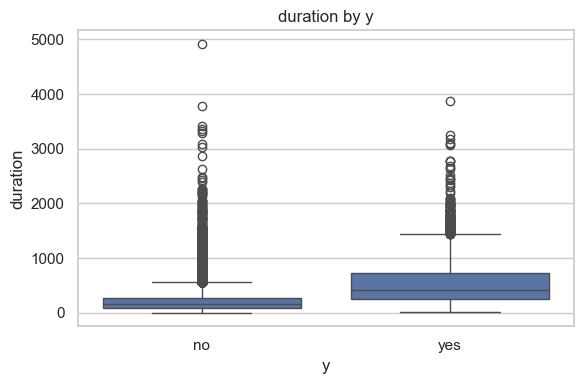

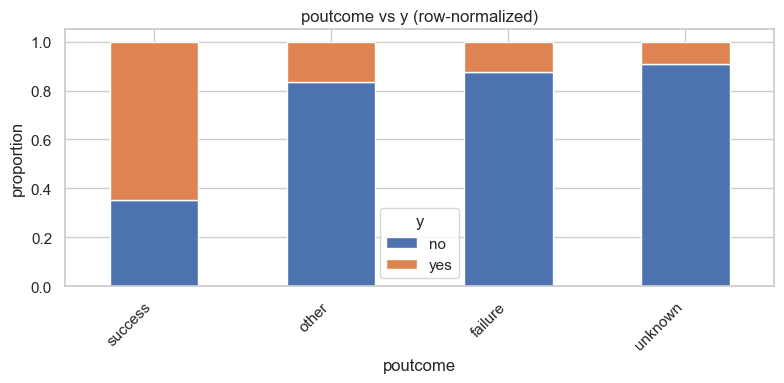

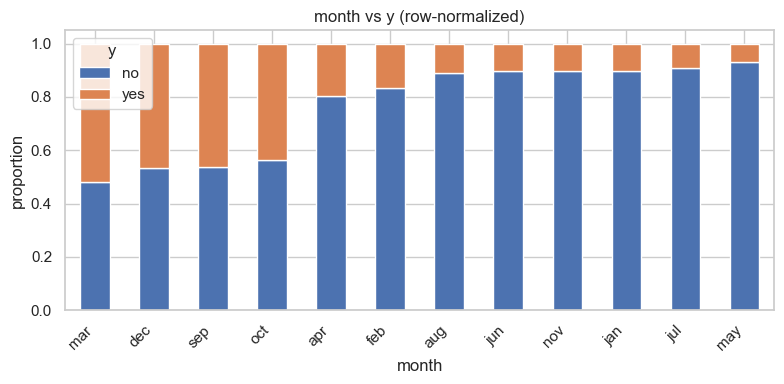

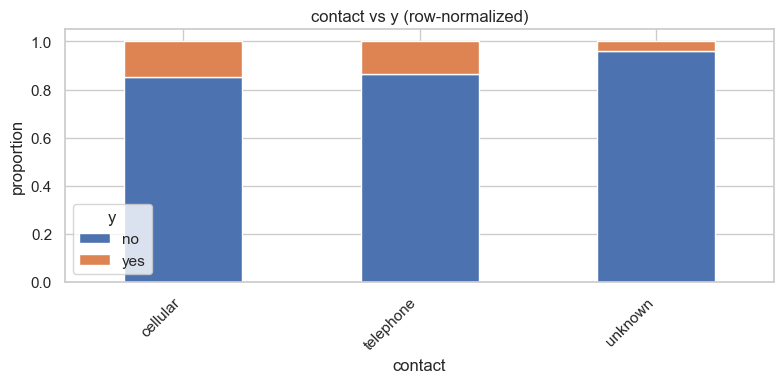

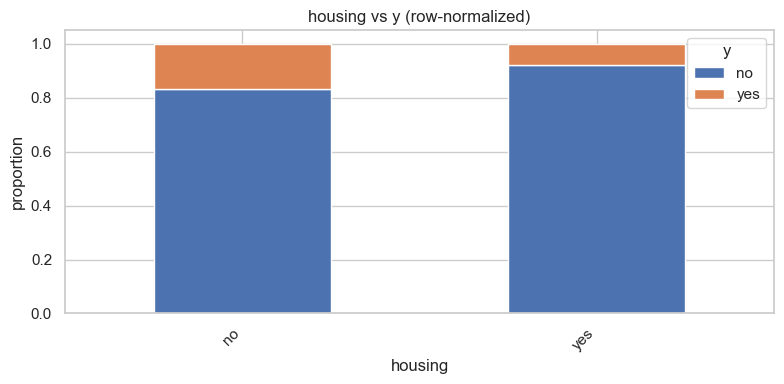

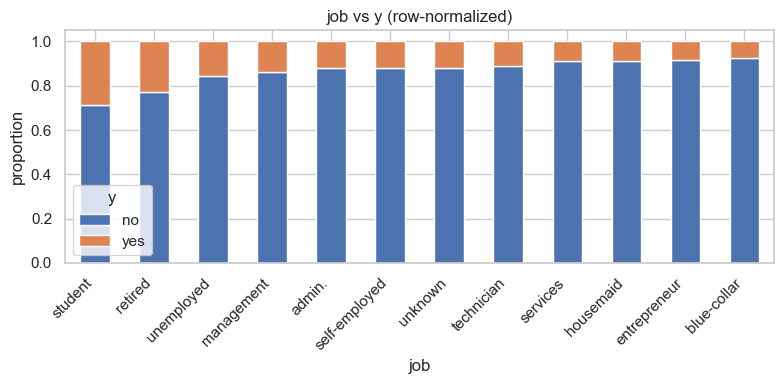

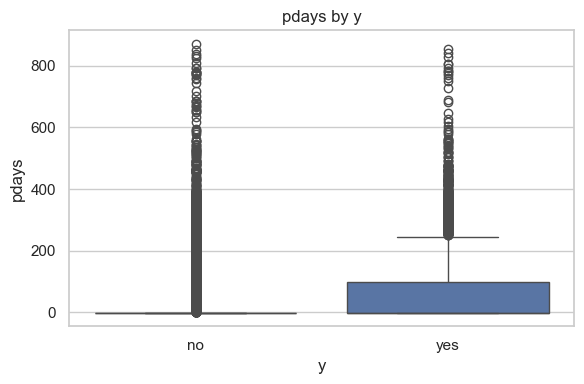

In [29]:
def plot_numeric_vs_target(df, col, target="y"):
	plt.figure(figsize=(6, 4))
	sns.boxplot(x=df[target], y=df[col])
	plt.title(f"{col} by {target}")
	plt.tight_layout()
	plt.show()

def plot_categorical_vs_target(df, col, target="y", order=None):
	ct = pd.crosstab(df[col], df[target], normalize="index")
	order = order or ct.sort_values(by=ct.columns[-1], ascending=False).index
	ct.loc[order].plot(kind="bar", stacked=True, figsize=(8, 4))
	plt.title(f"{col} vs {target} (row-normalized)")
	plt.ylabel("proportion")
	plt.xticks(rotation=45, ha="right")
	plt.tight_layout()
	plt.show()

for col in top_features:
	if col in numeric_cols:
		plot_numeric_vs_target(train, col)
	else:
		plot_categorical_vs_target(train, col)

## Multicollinearity (numeric feature-to-feature)

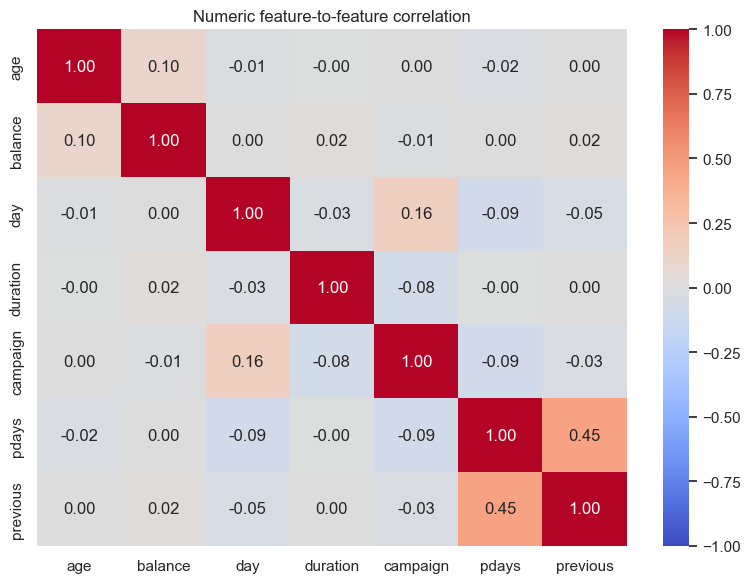

In [30]:
corr_matrix = train[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Numeric feature-to-feature correlation")
plt.tight_layout()
plt.show()

## Regression EDA — Primary Target: balance

balance vs. other numeric features (Pearson r):
age         0.098
duration    0.022
previous    0.017
campaign   -0.015
day         0.005
pdays       0.003
dtype: float64


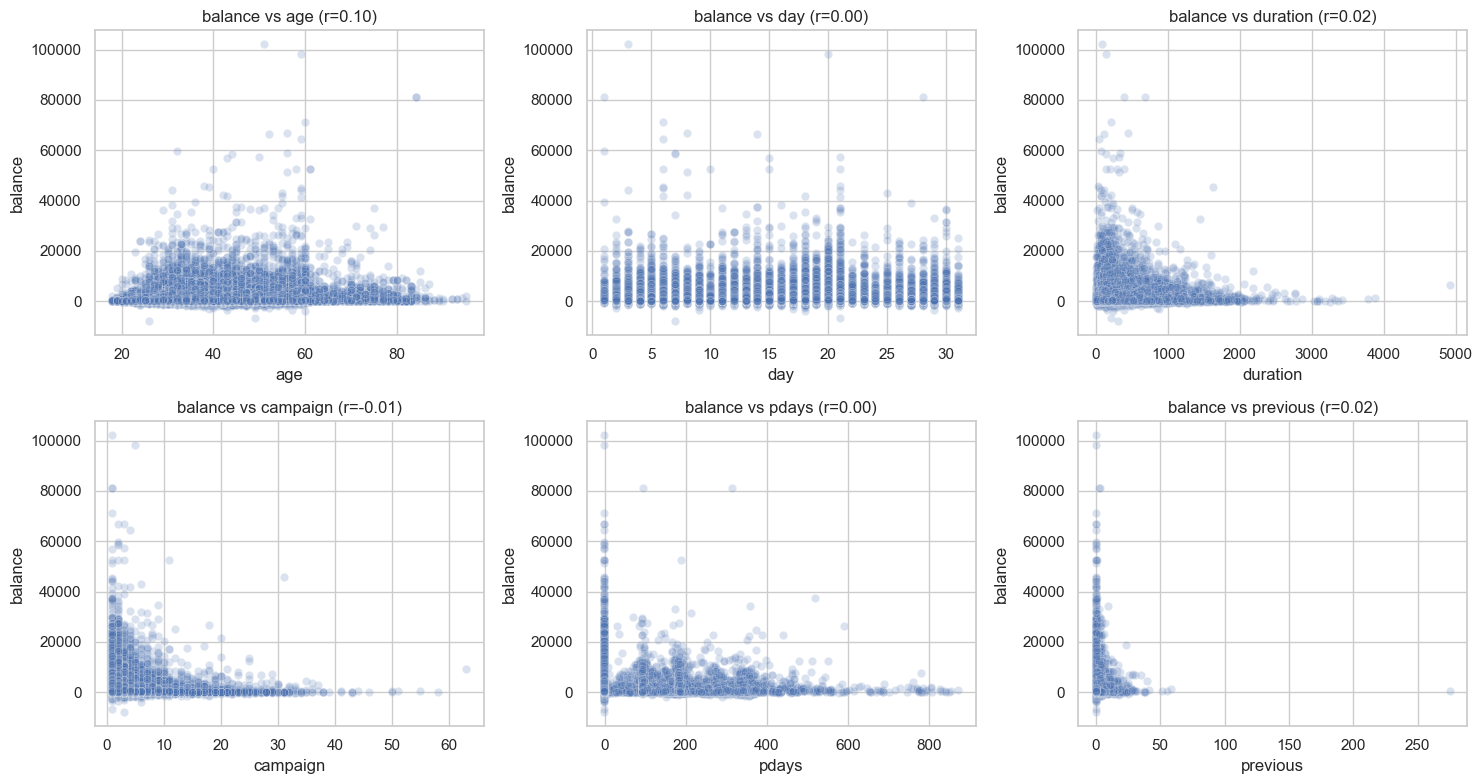

In [31]:
other_numeric = [c for c in numeric_cols if c != "balance"]

balance_corr = train[other_numeric].corrwith(train["balance"]).sort_values(key=abs, ascending=False)
print("balance vs. other numeric features (Pearson r):")
print(balance_corr.round(3))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, other_numeric):
	sns.scatterplot(x=train[col], y=train["balance"], alpha=0.2, ax=ax)
	ax.set_title(f"balance vs {col} (r={balance_corr[col]:.2f})")
plt.tight_layout()
plt.show()

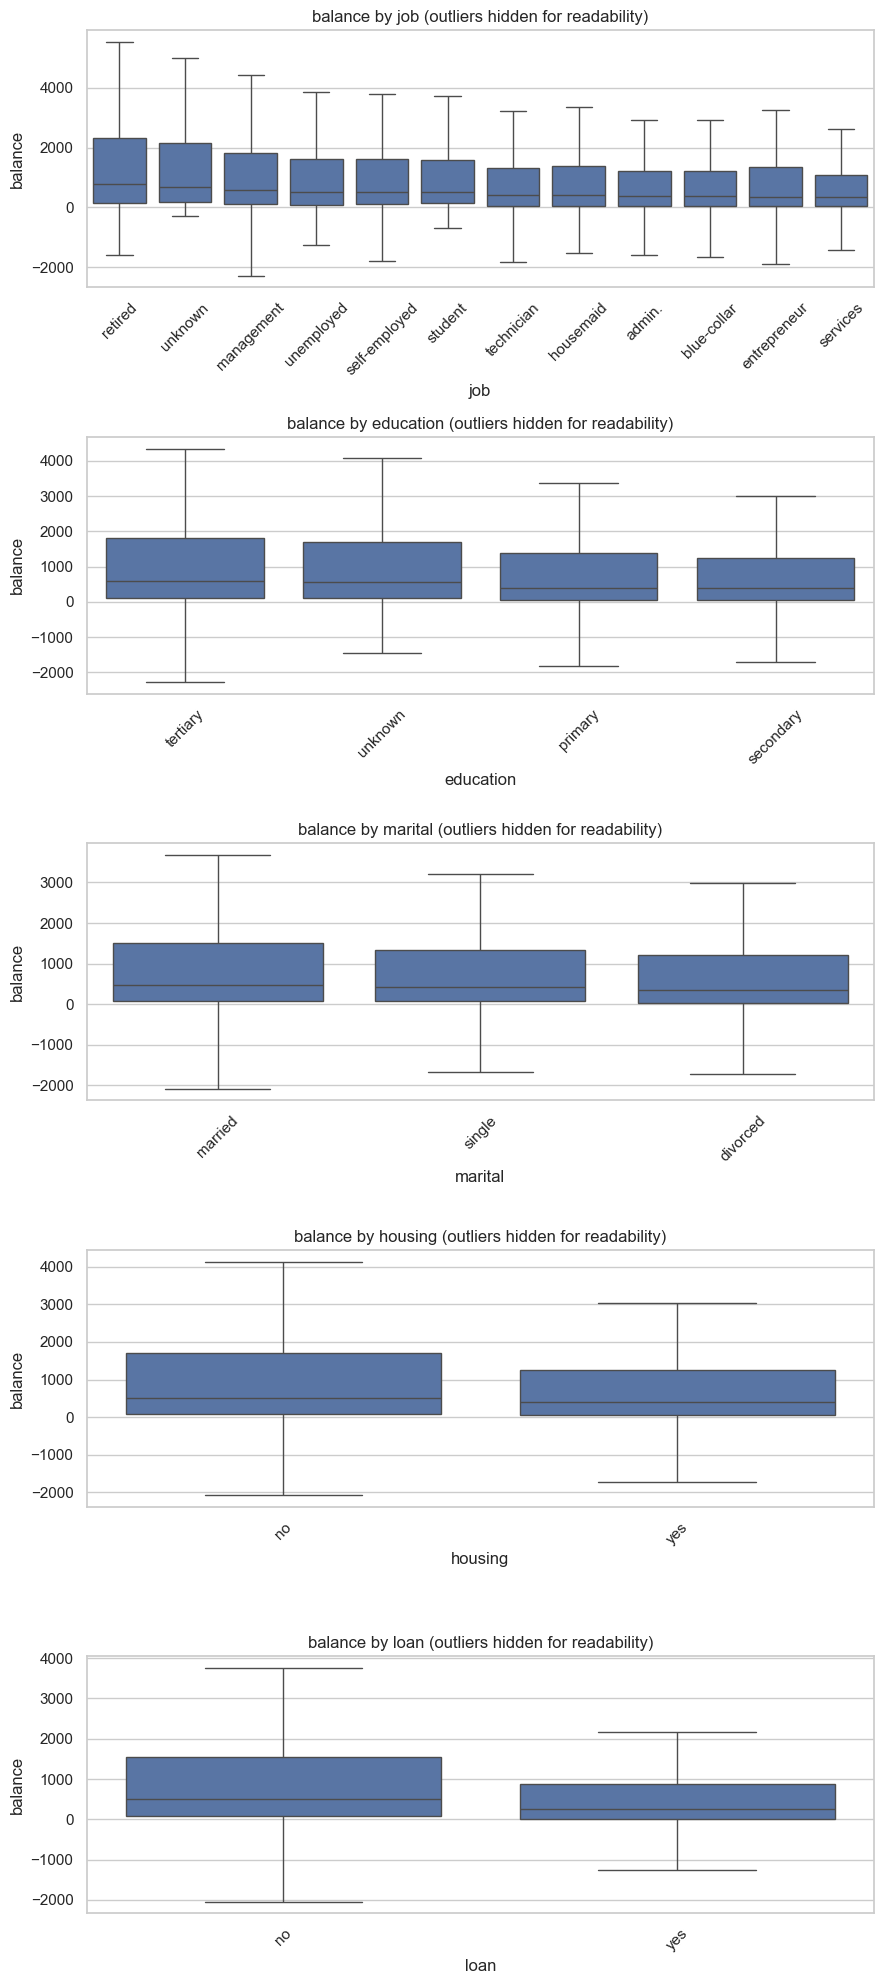

In [32]:
balance_categorical_cols = ["job", "education", "marital", "housing", "loan"]

fig, axes = plt.subplots(len(balance_categorical_cols), 1, figsize=(9, 4 * len(balance_categorical_cols)))
for ax, col in zip(axes, balance_categorical_cols):
	order = train.groupby(col)["balance"].median().sort_values(ascending=False).index
	sns.boxplot(x=train[col], y=train["balance"], order=order, ax=ax, showfliers=False)
	ax.set_title(f"balance by {col} (outliers hidden for readability)")
	ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Discussion — balance

## Regression EDA — Secondary Targets: duration, campaign


duration vs. other numeric features (Pearson r):
campaign   -0.085
day        -0.030
balance     0.022
age        -0.005
pdays      -0.002
previous    0.001
dtype: float64

campaign vs. other numeric features (Pearson r):
day         0.162
pdays      -0.089
duration   -0.085
previous   -0.033
balance    -0.015
age         0.005
dtype: float64


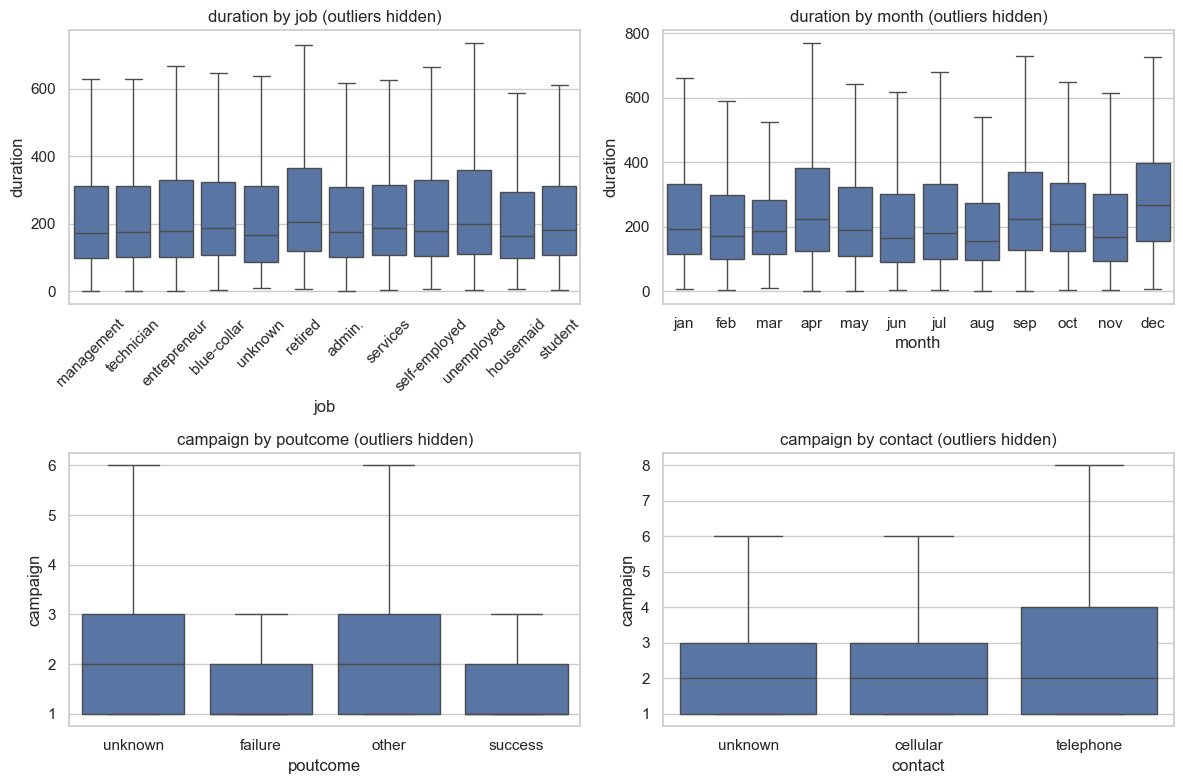


campaign is a discrete count (min=1), right-skewed — a modeling consideration for later (e.g. Poisson/negative-binomial-style target) rather than something to solve in EDA.


In [33]:
for target in ["duration", "campaign"]:
	other = [c for c in numeric_cols if c != target]
	print(f"\n{target} vs. other numeric features (Pearson r):")
	print(train[other].corrwith(train[target]).sort_values(key=abs, ascending=False).round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(x=train["job"], y=train["duration"], ax=axes[0, 0], showfliers=False)
axes[0, 0].set_title("duration by job (outliers hidden)")
axes[0, 0].tick_params(axis="x", rotation=45)
sns.boxplot(x=train["month"], y=train["duration"], order=month_order, ax=axes[0, 1], showfliers=False)
axes[0, 1].set_title("duration by month (outliers hidden)")
sns.boxplot(x=train["poutcome"], y=train["campaign"], ax=axes[1, 0], showfliers=False)
axes[1, 0].set_title("campaign by poutcome (outliers hidden)")
sns.boxplot(x=train["contact"], y=train["campaign"], ax=axes[1, 1], showfliers=False)
axes[1, 1].set_title("campaign by contact (outliers hidden)")
plt.tight_layout()
plt.show()

print(f"\ncampaign is a discrete count (min={train['campaign'].min()}), right-skewed — a modeling consideration "
      "for later (e.g. Poisson/negative-binomial-style target) rather than something to solve in EDA.")

## Deep Dive — Time/Seasonality (y)

In [34]:
N_CHUNKS = 20
chunk_id = pd.cut(np.arange(len(train)), bins=N_CHUNKS, labels=False)
seasonality = train.groupby(chunk_id).agg(
	n_calls=("y", "size"),
	y_rate=("y", lambda s: (s == "yes").mean()),
)
seasonality

,n_calls,y_rate
0,2261,0.021230
1,2261,0.038479
2,2260,0.031858
3,2261,0.042901
4,2260,0.045575
5,2261,0.050862
6,2260,0.071239
7,2261,0.057054
8,2260,0.060177
9,2261,0.061920


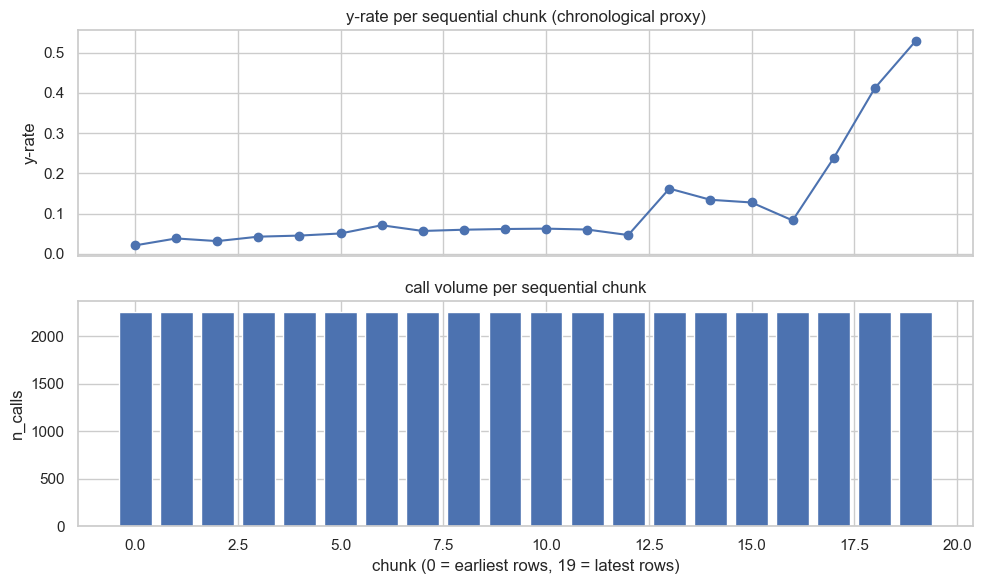

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(seasonality.index, seasonality["y_rate"], marker="o")
axes[0].set_title("y-rate per sequential chunk (chronological proxy)")
axes[0].set_ylabel("y-rate")
axes[1].bar(seasonality.index, seasonality["n_calls"])
axes[1].set_title("call volume per sequential chunk")
axes[1].set_ylabel("n_calls")
axes[1].set_xlabel("chunk (0 = earliest rows, 19 = latest rows)")
plt.tight_layout()
plt.show()

## Deep Dive — Categorical-Categorical Redundancy (y)

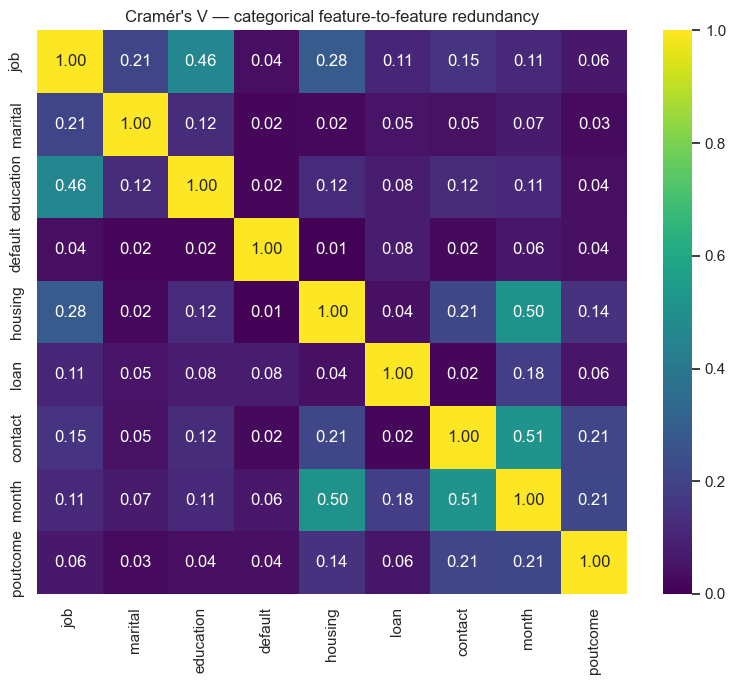

In [36]:
cat_redundancy_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

cramers_matrix = pd.DataFrame(index=cat_redundancy_cols, columns=cat_redundancy_cols, dtype=float)
for c1 in cat_redundancy_cols:
	for c2 in cat_redundancy_cols:
		cramers_matrix.loc[c1, c2] = 1.0 if c1 == c2 else cramers_v(train[c1], train[c2])

plt.figure(figsize=(8, 7))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Cramér's V — categorical feature-to-feature redundancy")
plt.tight_layout()
plt.show()

In [37]:
never_contacted = train["pdays"] == -1
poutcome_vs_pdays = pd.crosstab(train["poutcome"], never_contacted)
poutcome_vs_pdays.columns = ["pdays != -1 (previously contacted)", "pdays == -1 (never contacted)"]
poutcome_vs_pdays

,pdays != -1 (previously contacted),pdays == -1 (never contacted)
poutcome,,
failure,4901,0
other,1840,0
success,1511,0
unknown,5,36954


## Deep Dive — Interaction Effects (y)

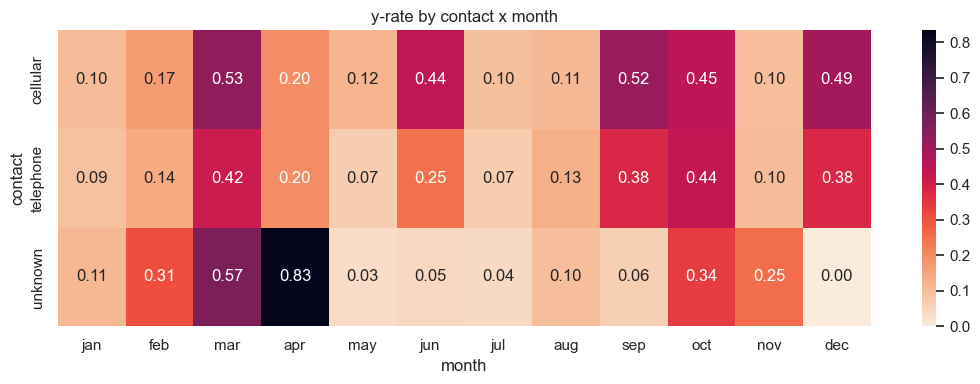

In [38]:
contact_month_rate = pd.crosstab(train["contact"], train["month"], values=y_binary, aggfunc="mean").reindex(columns=month_order)

plt.figure(figsize=(11, 4))
sns.heatmap(contact_month_rate, annot=True, fmt=".2f", cmap="rocket_r")
plt.title("y-rate by contact x month")
plt.tight_layout()
plt.show()

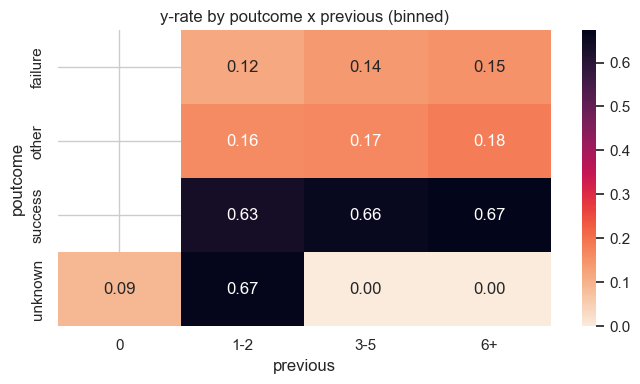

In [39]:
previous_binned = pd.cut(train["previous"], bins=[-1, 0, 2, 5, train["previous"].max()], labels=["0", "1-2", "3-5", "6+"])
poutcome_previous_rate = pd.crosstab(train["poutcome"], previous_binned, values=y_binary, aggfunc="mean")

plt.figure(figsize=(7, 4))
sns.heatmap(poutcome_previous_rate, annot=True, fmt=".2f", cmap="rocket_r")
plt.title("y-rate by poutcome x previous (binned)")
plt.tight_layout()
plt.show()

## Deep Dive — balance vs. y

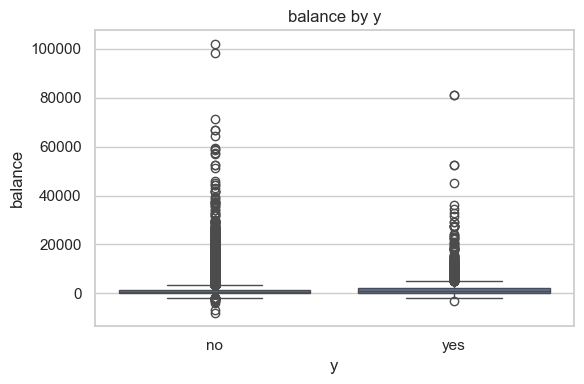

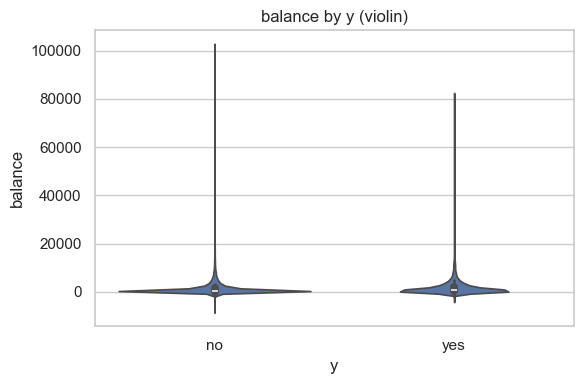

,median,mean,count
y,,,
no,417.0,1303.714969,39922
yes,733.0,1804.267915,5289


In [40]:
plot_numeric_vs_target(train, "balance")

fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(x=train["y"], y=train["balance"], ax=ax)
ax.set_title("balance by y (violin)")
plt.tight_layout()
plt.show()

balance_by_y = train.groupby("y")["balance"].agg(["median", "mean", "count"])
balance_by_y

## Deep Dive — Age-Binned balance Trend

In [41]:
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_bucket = pd.cut(train["age"], bins=age_bins)
age_balance = train.groupby(age_bucket, observed=True)["balance"].agg(["median", "mean", "count"])
age_balance

,median,mean,count
age,,,
"(18, 25]",362.5,902.733384,1324
"(25, 35]",373.0,1147.200116,15571
"(35, 45]",444.0,1319.575346,13856
"(45, 55]",506.0,1466.060955,9548
"(55, 65]",671.0,1958.455290,4149
"(65, 100]",1413.0,2822.002663,751


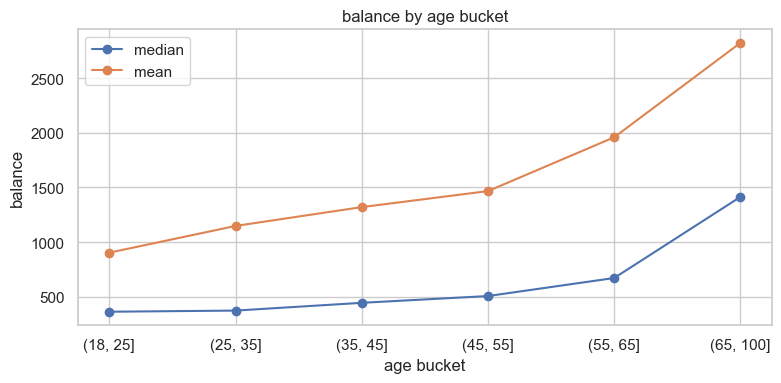

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))
x_labels = age_balance.index.astype(str)
ax.plot(x_labels, age_balance["median"], marker="o", label="median")
ax.plot(x_labels, age_balance["mean"], marker="o", label="mean")
ax.set_title("balance by age bucket")
ax.set_xlabel("age bucket")
ax.set_ylabel("balance")
ax.legend()
plt.tight_layout()
plt.show()